# 06. Business Recommendations and Final Report

## Objective

This notebook converts the findings from the earlier notebooks into a final
business-facing conclusion.

It focuses on:

- the main analytical findings
- what the findings mean for the business
- prioritised recommendations
- implementation actions
- KPIs for monitoring
- limitations
- final conclusion

No new hypothesis testing is performed here. The formal statistical analysis
was completed in Notebook 04, while business segmentation and opportunity
analysis were completed in Notebook 05.

The recommendations must remain consistent with the observed results.

# 1. Setup

The final report uses the persistent analytical DuckDB database and the
business-analysis outputs created in Notebook 05.

In [1]:
from pathlib import Path
import sys
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import get_duckdb_path

DUCKDB_PATH = get_duckdb_path()

BUSINESS_OUTPUT_DIR = (
    PROJECT_ROOT
    / "02_Data"
    / "05_Business_Analysis"
)

FINAL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "02_Data"
    / "06_Final_Report"
)

FINAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

if not DUCKDB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB database not found: {DUCKDB_PATH}"
    )

con = duckdb.connect(str(DUCKDB_PATH))

print(f"DuckDB version: {duckdb.__version__}")
print(f"Database: {DUCKDB_PATH}")

DuckDB version: 1.5.5
Database: D:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\04_DuckDB\olist_capstone.duckdb


# 2. Load Business Analysis Outputs

These outputs were generated in Notebook 05.

If an output is not available, the notebook stops rather than silently
creating a replacement result.

In [2]:
required_outputs = [
    "value_tier_summary.csv",
    "freight_summary.csv",
    "delivery_by_value.csv",
    "delivery_exposure.csv",
    "segment_expected_repeat_revenue.csv",
    "delivery_opportunity.csv",
    "delivery_sensitivity.csv",
    "freight_comparison.csv",
    "business_priority.csv"
]

missing_outputs = [
    file_name
    for file_name in required_outputs
    if not (BUSINESS_OUTPUT_DIR / file_name).exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Run Notebook 05 first. Missing outputs: "
        + ", ".join(missing_outputs)
    )

value_tier_summary = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "value_tier_summary.csv"
)

freight_summary = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "freight_summary.csv"
)

delivery_by_value = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "delivery_by_value.csv"
)

delivery_exposure = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "delivery_exposure.csv"
)

segment_expected_repeat_revenue = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "segment_expected_repeat_revenue.csv"
)

delivery_opportunity = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "delivery_opportunity.csv"
)

delivery_sensitivity = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "delivery_sensitivity.csv"
)

freight_comparison = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "freight_comparison.csv"
)

business_priority = pd.read_csv(
    BUSINESS_OUTPUT_DIR / "business_priority.csv"
)

print("Notebook 05 outputs loaded successfully.")

Notebook 05 outputs loaded successfully.


# 3. Executive Metrics

These are the headline figures used in the final report.

In [3]:
headline_metrics = con.sql("""
SELECT
    COUNT(*) AS customers,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
""").df()

display(headline_metrics)

,customers,unique_customers,repeat_customers,repeat_rate_pct
0,93254,93254,2877.0,3.085122


# 4. Delivery Finding

A lower repeat-purchase rate among customers whose first
order was late.

The final report should describe this as an **observed association**, not as
proof that late delivery directly caused the later purchase decision.

In [4]:
delivery_finding = con.sql("""
SELECT
    CASE
        WHEN first_order_late_flag = 1
            THEN 'Late'
        ELSE 'On-time / early'
    END AS delivery_group,

    COUNT(*) AS customers,

    SUM(is_repeat_customer) AS repeat_customers,

    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct

FROM customer_level_featured

WHERE first_order_late_flag IS NOT NULL
  AND is_repeat_customer IS NOT NULL

GROUP BY first_order_late_flag

ORDER BY first_order_late_flag
""").df()

display(delivery_finding)

on_time_rate = delivery_finding.loc[
    delivery_finding["delivery_group"] == "On-time / early",
    "repeat_rate_pct"
].iloc[0]

late_rate = delivery_finding.loc[
    delivery_finding["delivery_group"] == "Late",
    "repeat_rate_pct"
].iloc[0]

delivery_gap = on_time_rate - late_rate

print(
    f"Observed delivery repeat-rate gap: "
    f"{delivery_gap:.2f} percentage points"
)

,delivery_group,customers,repeat_customers,repeat_rate_pct
0,On-time / early,85662,2683.0,3.132077
1,Late,7592,194.0,2.555321


Observed delivery repeat-rate gap: 0.58 percentage points


# 5. Freight Finding

The freight result requires one correction relative to earlier drafts of
this analysis.

The original freight-burden band was built on freight **relative to
order value** (freight ÷ price). That ratio is mechanically related to
order value itself, so a cheap order with ordinary freight can land in
the same band as a genuinely high-freight order. The band was rebuilt in
Notebook 03 on **absolute freight value**; both versions are compared
side by side in Notebook 04, Section 11b.

The two versions do not agree. The original ratio-based band showed a
statistically significant difference (high-freight repeat rate 3.43% vs
low-freight 2.86%, p = 0.0004). The corrected, value-based band shows an
essentially zero difference (3.17% vs 3.16%, p = 0.968) -- not merely
weaker, but absent. This confirms the original result was a mechanical
artifact of the ratio's confound with order value, not a genuine
relationship. The confirmatory logistic regression agrees: first-order
freight value is not a significant predictor of repeat purchase once
order value is controlled for (Notebook 04, Section 13).

Therefore the final report should **not** recommend a retention
intervention based on an assumed freight effect in either direction.
This conclusion rests on the corrected, order-value-controlled evidence,
not the original ratio-based comparison.


In [5]:
display(freight_comparison)

low_freight_rate = freight_comparison.loc[
    freight_comparison["freight_burden_band"]
    == "Low freight burden",
    "repeat_rate_pct"
].iloc[0]

high_freight_rate = freight_comparison.loc[
    freight_comparison["freight_burden_band"]
    == "High freight burden",
    "repeat_rate_pct"
].iloc[0]

freight_gap = high_freight_rate - low_freight_rate

print(
    f"High-freight minus low-freight repeat-rate difference: "
    f"{freight_gap:.2f} percentage points"
)

print(
    "Conclusion: freight burden is not presented as a demonstrated "
    "retention-loss driver."
)

,freight_burden_band,customers,repeat_rate_pct
0,High freight burden,23309,3.166159
1,Low freight burden,23325,3.159700


High-freight minus low-freight repeat-rate difference: 0.01 percentage points
Conclusion: freight burden is not presented as a demonstrated retention-loss driver.


# 6. Customer-Value Finding

Customer-value tiers show how repeat purchase and order value vary across
the customer population.

The final recommendation should not assume that a higher-value customer is
automatically more likely to repeat. The business decision should consider
both customer value and exposure to the delivery issue.

In [6]:
display(
    value_tier_summary[
        [
            "value_tier",
            "customers",
            "repeat_customers",
            "repeat_rate_pct",
            "avg_order_value",
            "median_order_value"
        ]
    ]
)

,value_tier,customers,repeat_customers,repeat_rate_pct,avg_order_value,median_order_value
0,Low,23400,753.0,3.217949,28.613741,29.00
1,Medium-Low,23293,755.0,3.241317,63.944420,60.00
2,Medium-High,23401,687.0,2.935772,115.103533,113.45
3,High,23160,682.0,2.944732,344.036777,230.00


# 7. Delivery vs Value-Tier Finding

This table is the main bridge between the diagnostic result and the business
recommendation.

It shows where the observed delivery gap is largest and how many customers
are exposed.

In [7]:
delivery_priority = delivery_by_value.merge(
    delivery_exposure[
        [
            "value_tier",
            "late_first_order_customers",
            "late_customer_pct"
        ]
    ],
    on="value_tier",
    how="left"
)

delivery_priority = delivery_priority.sort_values(
    "retention_gap_pp",
    ascending=False
)

display(delivery_priority)

,value_tier,on_time_customers,late_customers,on_time_repeat_rate_pct,late_repeat_rate_pct,retention_gap_pp,avg_order_value,late_first_order_customers,late_customer_pct
0,Low,21674,1726,3.285042,2.375435,0.909607,28.616557,1726.0,7.376068
3,High,21094,2066,3.019816,2.178122,0.841694,356.038253,2066.0,8.920553
2,Medium-High,21499,1902,2.976883,2.471083,0.505800,115.568181,1902.0,8.127858
1,Medium-Low,21395,1898,3.243749,3.213909,0.029839,64.025759,1898.0,8.148371


# 8. Segment Expected Repeat Revenue

This measure provides context for the value of retaining customers.

It should be interpreted as an expected value of one repeat purchase at the
segment level, not as customer lifetime value.

In [8]:
display(segment_expected_repeat_revenue)

,value_tier,customers,avg_order_value,repeat_rate_pct,segment_expected_repeat_revenue
0,Low,23400,28.613741,3.217949,0.920775
1,Medium-Low,23293,63.944420,3.241317,2.072641
2,Medium-High,23401,115.103533,2.935772,3.379177
3,High,23160,344.036777,2.944732,10.130962


# 9. Delivery Opportunity

This is not a forecast of actual recovered revenue. It represents the value
implied by the observed gap under the assumptions used in the calculation.

In [9]:
display(
    delivery_opportunity[
        [
            "value_tier",
            "late_customers",
            "avg_order_value",
            "retention_gap_pp",
            "gross_delivery_opportunity"
        ]
    ]
)

gross_delivery_opportunity = (
    delivery_opportunity[
        "gross_delivery_opportunity"
    ].sum()
)

print(
    f"Total gross delivery opportunity: "
    f"{gross_delivery_opportunity:,.2f}"
)

,value_tier,late_customers,avg_order_value,retention_gap_pp,gross_delivery_opportunity
0,Low,1726,28.616557,0.909607,449.274930
1,Medium-Low,1898,64.025759,0.029839,36.260814
2,Medium-High,1902,115.568181,0.505800,1111.801486
3,High,2066,356.038253,0.841694,6191.291530


Total gross delivery opportunity: 7,788.63


# 10. Recovery Sensitivity

Because the dataset does not contain intervention effectiveness, the
analysis uses sensitivity scenarios rather than claiming one exact recovery
rate.

The scenarios are illustrative and should be replaced by business-approved
estimates if they become available.

,intervention_effectiveness,gross_delivery_opportunity,scenario_recoverable_revenue
0,0.10,7788.62876,778.862876
1,0.25,7788.62876,1947.157190
2,0.50,7788.62876,3894.314380


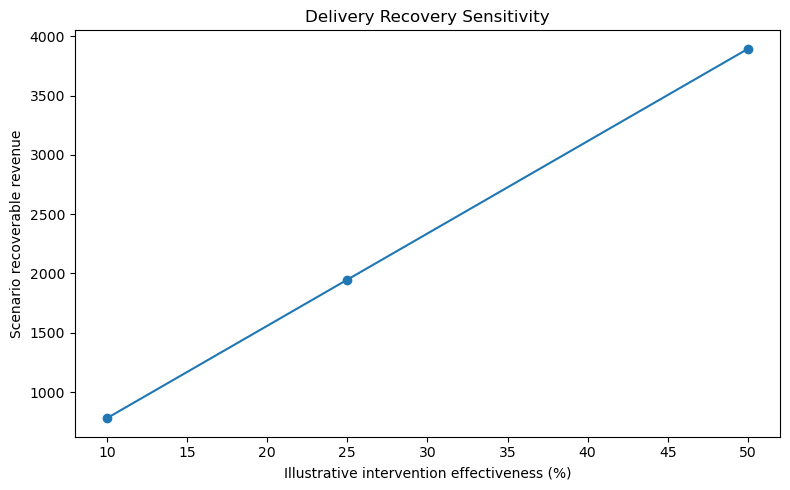

In [10]:
display(delivery_sensitivity)

plt.figure(figsize=(8, 5))

plt.plot(
    delivery_sensitivity["intervention_effectiveness"] * 100,
    delivery_sensitivity["scenario_recoverable_revenue"],
    marker="o"
)

plt.xlabel("Illustrative intervention effectiveness (%)")
plt.ylabel("Scenario recoverable revenue")
plt.title("Delivery Recovery Sensitivity")

plt.tight_layout()
plt.show()

# 11. Recommendation 1 — Improve First-Order Delivery Reliability

## Recommendation

Prioritise first-order delivery reliability as the main retention-related
operational improvement area.

## Why

The analysis found:

- lower repeat purchase among customers with late first orders
- a measurable observed gap between late and on-time/early groups
- a formal interaction test found no statistically significant difference
  in this effect across customer-value tiers (Notebook 04, Section 11a,
  p = 0.341) -- the delivery effect should be treated as consistent across
  segments, not stronger in any particular tier

## Suggested actions

1. Monitor first-order late-delivery rate as a dedicated KPI.
2. Identify the operational stages contributing to late first orders.
3. Prioritise high-exposure customer segments where the delivery gap is
   commercially meaningful.
4. Review carrier, seller and fulfilment performance for repeated late
   first-order patterns.
5. Test targeted delivery improvements before scaling them across the full
   customer base.

# 12. Recommendation 2 — Prioritise by Exposure and Value, Not by a Differential Effect

No statistically significant difference found in the delivery effect across customer-value tiers
(p = 0.341). The descriptive spread in the retention gap (0.03 to 0.91
percentage points across tiers) is consistent with sampling noise around
one overall effect, not genuine segment-level variation.

Priority should be based on a combination of:

- customer value
- number of late first orders
- expected value of a repeat purchase

The priority table below supports this approach. It should not be read as evidence that the underlying delivery
effect itself differs by segment.

In [11]:
priority_report = business_priority[
    [
        "value_tier",
        "on_time_customers",
        "late_customers",
        "on_time_repeat_rate_pct",
        "late_repeat_rate_pct",
        "retention_gap_pp",
        "avg_order_value",
        "gross_delivery_opportunity"
    ]
].copy()

priority_report = priority_report.sort_values(
    "gross_delivery_opportunity",
    ascending=False
)

display(priority_report)

,value_tier,on_time_customers,late_customers,on_time_repeat_rate_pct,late_repeat_rate_pct,retention_gap_pp,avg_order_value,gross_delivery_opportunity
0,High,21094,2066,3.019816,2.178122,0.841694,356.038253,6191.291530
1,Medium-High,21499,1902,2.976883,2.471083,0.505800,115.568181,1111.801486
2,Low,21674,1726,3.285042,2.375435,0.909607,28.616557,449.274930
3,Medium-Low,21395,1898,3.243749,3.213909,0.029839,64.025759,36.260814


# 13. Recommendation 3 — Monitor Freight, Do Not Treat It as a Retention Problem

The freight analysis does not support the original expectation that higher
freight burden reduces repeat purchase.

Therefore:

- do not claim that reducing freight will automatically improve retention
- do not calculate freight revenue-at-risk from the observed retention result
- continue monitoring freight for margin and customer-experience purposes
- use a separate analysis if the business wants to study freight economics

This keeps the recommendation aligned with the observed evidence.


# 14. Recommendation 4 — Use Controlled Operational Testing

The observational analysis identifies a relationship but does not establish
causality.

Before committing a large operational budget, the business should test
whether improving delivery performance changes repeat behaviour.

A suitable future test could compare:

- customers receiving an improved delivery experience
- comparable customers receiving the existing experience

The success measure should be repeat purchase within a clearly defined
follow-up period.

# 15. KPI Framework

The following KPIs can be used to monitor the recommended delivery
improvement programme.

In [12]:
kpi_framework = pd.DataFrame({
    "KPI": [
        "First-order late-delivery rate",
        "First-order on-time / early rate",
        "Repeat-purchase rate",
        "Repeat-purchase rate after on-time / early first order",
        "Repeat-purchase rate after late first order",
        "Delivery retention gap",
        "Average first-order value",
        "Segment Expected Repeat Revenue",
        "Scenario recoverable revenue"
    ],
    "Purpose": [
        "Monitor delivery performance",
        "Monitor successful delivery performance",
        "Track overall retention",
        "Track repeat behaviour for successful deliveries",
        "Track repeat behaviour for late deliveries",
        "Monitor the observed delivery-retention difference",
        "Monitor customer value",
        "Estimate value represented by a repeat purchase",
        "Evaluate intervention scenarios"
    ],
    "Recommended_frequency": [
        "Weekly / monthly",
        "Weekly / monthly",
        "Monthly",
        "Monthly",
        "Monthly",
        "Monthly",
        "Monthly",
        "Monthly",
        "Scenario review"
    ]
})

display(kpi_framework)

,KPI,Purpose,Recommended_frequency
0,First-order late-delivery rate,Monitor delivery performance,Weekly / monthly
1,First-order on-time / early rate,Monitor successful delivery performance,Weekly / monthly
2,Repeat-purchase rate,Track overall retention,Monthly
3,Repeat-purchase rate after on-time / early fir...,Track repeat behaviour for successful deliveries,Monthly
4,Repeat-purchase rate after late first order,Track repeat behaviour for late deliveries,Monthly
5,Delivery retention gap,Monitor the observed delivery-retention differ...,Monthly
6,Average first-order value,Monitor customer value,Monthly
7,Segment Expected Repeat Revenue,Estimate value represented by a repeat purchase,Monthly
8,Scenario recoverable revenue,Evaluate intervention scenarios,Scenario review


# 16. Implementation Roadmap

## Phase 1 — Diagnose

- identify the main sources of first-order delivery delays
- identify the highest-exposure customer segments
- establish baseline KPIs

## Phase 2 — Pilot

- implement targeted delivery improvements
- measure first-order delivery performance
- compare subsequent repeat behaviour

## Phase 3 — Evaluate

- compare pilot and baseline performance
- calculate incremental repeat-purchase impact
- compare the observed benefit with intervention cost

## Phase 4 — Scale

- expand only interventions that show a sustainable improvement
- continue monitoring customer value and delivery performance

# 17. Limitations

The final report should explicitly acknowledge the following limitations:

1. The dataset is observational.
2. Association does not prove causality.
3. The repeat-purchase definition is based on the analytical population
   constructed in the earlier notebooks.
4. The dataset does not directly observe customer motivations.
5. Intervention effectiveness is not available in the source data.
6. Revenue-opportunity calculations are therefore scenario estimates.
7. Seller and category findings are descriptive and may be affected by
   differences in customer mix.
8. Freight burden did not show the expected negative retention pattern
   under either banding tested, so it should not be presented as a
   proven retention problem.
9. The analysis does not estimate long-term customer lifetime value.
10. The analytical population excludes customers whose first order was
    never delivered (n=2,842). This exclusion is necessary to measure
    delivery *lateness*, but is not neutral: the excluded population's
    repeat rate is 4.22%, significantly higher than the 3.09% retained
    population (p = 0.0006, Notebook 02, Section 10a). The exclusion is
    therefore conservative -- it does not inflate the measured H1 effect,
    if anything it removes a higher-retention group from the analysis.
11. The value-tier segment-priority recommendation (Recommendation 2) is
    a resource-allocation choice, not evidence of a differential effect:
    a formal interaction test found no statistically significant
    difference in the delivery effect across customer-value tiers
    (p = 0.341, Notebook 04, Section 11a).


# 18. Final Findings

## Finding 1 — Repeat purchase is relatively uncommon

The overall repeat-purchase rate is low, so small changes in retention can
still be relevant when applied across a large customer population.

## Finding 2 — First-order delivery performance is the main retention-related
signal

Customers with late first orders showed a lower repeat-purchase rate than
customers whose first orders were on time or early.

## Finding 3 — No demonstrated difference in the delivery effect by customer value

A formal interaction test found no statistically significant difference in
the delivery-retention effect across customer-value tiers (p = 0.341). The
business can still prioritise segments by size and value for resource
allocation, but should not claim the delivery problem itself is worse for
any particular value tier.

## Finding 4 — Freight shows no significant relationship with repeat purchase

Under the corrected, value-based freight band, high- and low-freight
customers show essentially identical repeat rates (3.17% vs 3.16%,
not significant). The originally observed "higher repeat rate" in the
high-freight group was an artifact of the ratio-based band being
mechanically confounded with order value. Freight burden should not be
presented as a demonstrated retention driver in either direction.

## Finding 5 — Revenue opportunity should be treated as a scenario

The delivery opportunity depends on how much of the observed retention gap an
actual intervention could recover. The dataset does not provide that
effectiveness directly.

# 19. Final Business Recommendation

### Primary recommendation

**Focus retention-improvement efforts on first-order delivery reliability.**

Prioritise customer segments by exposure (number of late first orders) and
customer value, to allocate limited operational effort where the absolute
opportunity is largest. This is a resource-allocation ranking, not a claim
that the delivery effect is stronger in any one segment -- a formal test
found no significant difference in the effect itself across value tiers.

### Secondary recommendation

**Do not prioritise freight reduction as a retention intervention based on
this analysis alone.**

The observed freight relationship does not support that conclusion.

### Measurement recommendation

Use a controlled operational test to determine whether improving first-order
delivery actually produces an incremental improvement in repeat purchase.

This converts the current observational finding into a measurable business
decision.

# 20. Export Final Report Tables

In [13]:
final_tables = {
    "headline_metrics": headline_metrics,
    "delivery_finding": delivery_finding,
    "freight_comparison": freight_comparison,
    "value_tier_summary": value_tier_summary,
    "delivery_priority": delivery_priority,
    "segment_expected_repeat_revenue": segment_expected_repeat_revenue,
    "delivery_opportunity": delivery_opportunity,
    "delivery_sensitivity": delivery_sensitivity,
    "kpi_framework": kpi_framework
}

for name, df in final_tables.items():
    df.to_csv(
        FINAL_OUTPUT_DIR / f"{name}.csv",
        index=False
    )

print(f"Final report tables saved to: {FINAL_OUTPUT_DIR}")

Final report tables saved to: d:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\02_Data\06_Final_Report


# 21. Summary

1. Repeat purchase is relatively low across the analytical population.
2. Late first-order delivery is associated with lower repeat purchase.
3. A formal test found no significant difference in the delivery effect
   across customer-value tiers; segment prioritisation is a resource-
   allocation choice, not evidence of a differential effect.
4. Delivery reliability should therefore be the primary retention-related
   operational focus.
5. High freight burden does not show the expected negative relationship with
   repeat purchase.
6. Freight should not be presented as a proven retention-loss driver.
7. Delivery revenue opportunity should be presented as a scenario, not a
   guaranteed forecast.
8. A controlled operational test is recommended before scaling a large
   intervention.

In [14]:
print("=== FINAL BUSINESS RECOMMENDATION ===")
print()
print("Primary focus: improve first-order delivery reliability.")
print("Prioritisation: combine delivery exposure, retention gap and customer value.")
print("Freight: monitor, but do not treat as a demonstrated retention-loss driver.")
print("Next step: validate the delivery relationship through a controlled operational test.")

=== FINAL BUSINESS RECOMMENDATION ===

Primary focus: improve first-order delivery reliability.
Prioritisation: combine delivery exposure, retention gap and customer value.
Freight: monitor, but do not treat as a demonstrated retention-loss driver.
Next step: validate the delivery relationship through a controlled operational test.


# 22. Close DuckDB Connection

In [15]:
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
